In [ ]:
from data.loader import load_data, encode_categoricals
from data.preparation import add_derived_columns, filter_crops
from config import CampaignPaths, get_campaign_paths
from column_taxonomy import SOBOL_FEATURES, CATEGORICAL_FEATURES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("analysis.pipeline")

In [25]:
# 1. Load data & preview
CAMPAIGN_NAME = "sobol_S11111_n2048"
campaign = get_campaign_paths(CAMPAIGN_NAME)

num_features = [feat for feat in SOBOL_FEATURES if feat not in CATEGORICAL_FEATURES]
cat_features = [feat for feat in SOBOL_FEATURES if feat in CATEGORICAL_FEATURES]

df = load_data(campaign.raw_meta)
n_rows_bf, n_cols_bf = df.shape
df = add_derived_columns(df)
df, _ = filter_crops(df, excluded_crops=["rape"])
df, _ = encode_categoricals(df, features=SOBOL_FEATURES, method="sklearn")
n_rows_pr, n_cols_pr = df.shape
logger.info(f"✅ Data loaded & prepared:")
logger.info(f"Raw data:  {n_rows_bf} rows x {n_cols_bf} columns")
logger.info(f"Prep data: {n_rows_pr} rows x {n_cols_pr} columns")

2026-04-10 11:58:51 [INFO] data.loader — 📂 Loading meta_table_sobol_S11111_n2048.parquet  (format: parquet, engine: pandas)
2026-04-10 11:58:51 [INFO] data.loader — ✅ Loaded: 96820 rows × 128 columns
2026-04-10 11:58:51 [INFO] data.preparation — Adding derived columns
2026-04-10 11:58:51 [INFO] data.preparation —    ✓ Added 'Harvest_Year_Absolute' (normalised per SimID)
2026-04-10 11:58:51 [INFO] data.preparation —    ✓ Added 'Rotation' flag (58020 / 96820 cycles in rotation)
2026-04-10 11:58:51 [INFO] data.preparation —    ✓ Filled 38800 NaN values in 'rot_id' with 'monoculture'
2026-04-10 11:58:51 [INFO] data.preparation —    ✓ Filled 58020 NaN values in 'main_crop' with 'rotation'
2026-04-10 11:58:51 [INFO] data.preparation — Filtering crops: ['rape']
2026-04-10 11:58:51 [INFO] data.preparation —    ✗ Excluded crops [rape]: 19340 rows removed (20.0%)
2026-04-10 11:58:51 [INFO] data.loader — 🏷️  Encoding 3 categorical features (method='sklearn', fit=True)
2026-04-10 11:58:52 [INFO] d

# Distribution générale des outputs clés

In [13]:
df.groupby('SimID')['yield_AF'].mean().describe()

count    1937.000000
mean        4.993744
std         2.704731
min         0.000000
25%         2.701980
50%         5.324047
75%         7.258549
max        10.325492
Name: yield_AF, dtype: float64

*yield_AF*

La distribution du rendement moyen par simulation (moyenné sur les ~40 cycles de simulation) présente une étendue cohérente, allant de *0* à *10.3 t/ha* avec une **moyenne** de *5.0 t/ha* et un **écart-type** de *2.7 t/ha*. La **médiane** (*5.3 t/ha*) est **proche de la moyenne**, suggérant une distribution **relativement symétrique au niveau *SimID***.
Cependant, la présence d'un **minimum à 0** indique l'existence de **simulations défaillantes** qu'il conviendra d'identifier et de traiter séparément.
La dispersion observée reflète la diversité des conditions environnementales et des espèces cultivées couverte par le plan d'expérience Sobol.

In [26]:
df[df['Cycle_Nb'] == df.groupby('SimID')['Cycle_Nb'].transform('max')]['tree_height_AF'].describe()

count    2904.000000
mean       12.649642
std        10.604128
min         0.750016
25%         1.291320
50%        12.971564
75%        21.674521
max        38.915665
Name: tree_height_AF, dtype: float64

In [27]:
df[df['Cycle_Nb'] == df.groupby('SimID')['Cycle_Nb'].transform('max')]['carbonStem_AF'].describe()

count    2904.000000
mean      364.875465
std       563.256419
min         0.007789
25%         0.162380
50%       106.838544
75%       523.459020
max      3712.318826
Name: carbonStem_AF, dtype: float64

*tree_height_AF et carbonStem_AF*

Les distributions de la hauteur finale des arbres et du stock de carbone révèlent une **bimodalité** très marquée, caractéristique d'un mélange de deux populations structurellement distinctes. 

-> Pour *tree_height_AF*, le **premier quartile** (*1.29 m*) est **très éloigné de la médiane** (*12.97 m*) et du **troisième quartile** (*21.67 m*), signalant qu'**environ 25% des simulations produisent des arbres dont la croissance est quasi nulle sur 40 ans**. 

-> Cette bimodalité est encore plus prononcée pour *carbonStem_AF* : la **médiane** (*106.8 kgC/arbre*) est **inférieure à la moyenne** (*364.9 kgC/arbre*), avec un **écart-type** (*563.3*) **supérieur à la moyenne** — signe classique d'une distribution à queue très lourde ou d'un mélange de distributions. 

Ces observations impliquent que tout méta-modèle entraîné sur l'ensemble des données **sans distinction de régime** sera **structurellement biaisé**, ses résidus ne suivant aucune distribution homogène.

# Diagnostic des simulations arboricoles défaillantes

In [15]:
# 2.1 Tree failures

# --- 1a. Hauteur finale par SimID ---
last_cycle = df.loc[df.groupby('SimID')['Cycle_Nb'].idxmax(),
                    [f for f in df.columns]].copy()

TREE_FAIL_THRESHOLD = 1.0  # kg.C / tree
last_cycle['tree_failed'] = last_cycle['carbonStem_AF'] < TREE_FAIL_THRESHOLD

print("=== Arbres défaillants ===")
print(last_cycle['tree_failed'].value_counts())
print(f"\nTaux d'échec : {last_cycle['tree_failed'].mean():.1%}")

# --- 1b. Features NUMERIQUES : moyenne par groupe ---

print("\n=== Features numériques : défaillants vs OK ===")
comp_num = last_cycle.groupby('tree_failed')[num_features].mean().T.round(3)
comp_num.columns = ['OK (False)', 'Défaillant (True)']
comp_num['delta'] = comp_num['Défaillant (True)'] - comp_num['OK (False)']
print(comp_num)

# --- 1c. Features CATEGORIELLES : fréquences par groupe ---
print("\n=== Features catégorielles : distribution par groupe ===")
for col in cat_features:
    print(f"\n  [{col}]")
    ct = pd.crosstab(last_cycle['tree_failed'], last_cycle[col], normalize='index').round(3)
    print(ct)

=== Arbres défaillants ===
tree_failed
False    1277
True      660
Name: count, dtype: int64

Taux d'échec : 34.1%

=== Features numériques : défaillants vs OK ===
                  OK (False)  Défaillant (True)  delta
plotWidth             15.404             15.385 -0.019
plotHeight            10.410             10.224 -0.186
strip_width            2.019              1.953 -0.066
northOrientation      89.940             91.126  1.186
Rotation               0.493              0.512  0.019
soilDepth              4.706              4.726  0.020
sand                  52.872             44.318 -8.554
clay                  23.314             29.868  6.554
stone                 18.919             22.010  3.091
waterTable             0.491              0.514  0.023
w_peak_doy            60.509             60.286 -0.223
w_amp                  4.005              3.983 -0.022
w_mean                -6.530             -6.642 -0.112
latitude              45.887             46.214  0.327
longitude  

*Taux d'échec et définition*

En fixant un seuil de défaillance à un stock de carbone final inférieur à *1 kgC/arbre*, *34.1%* des simulations (*660 sur 1937*) sont classées comme **arboricoles défaillantes**. Ce taux élevé ne reflète pas nécessairement un défaut du modèle Hi-sAFe : il traduit la couverture volontairement large du plan d'expérience Sobol, qui explore des combinaisons pédo-climatiques extrêmes, pas forcément viables pour l'arbre. Ces configurations existent néanmoins dans l'espace pédologique français et sont donc traitées explicitement.


*Structure des échecs dans l'espace des features*

> L'analyse comparative des features moyennes entre simulations défaillantes et non-défaillantes révèle que les variables pédologiques **texturales** sont les **principaux déterminants de l'échec arboricole**, avec des deltas significatifs sur *clay* (+6.6 points), *stone* (+3.1 points) et *sand* (-8.6 points).
> 
> Les **variables de géométrie de la parcelle** (*plotWidth*, *plotHeight*, *strip_width*) et les **paramètres de nappe** sont en revanche quasi-identiques entre les deux groupes.
> 
> La **latitude** présente un delta modeste (+0.33°) mais la **longitude** montre un **signal notable** (-0.83°), suggérant que les zones continentales de l'Est de la France sont **légèrement surreprésentées parmi les simulations défaillantes**. 
> 
> Les **variables catégorielles** (*main_crop*, *period*, *w_type*) ne montrent **aucune discrimination** entre les deux groupes, confirmant que l'échec arboricole est un **phénomène principalement édapho-géographique**, **indépendant du système cultural ou de la période climatique**.


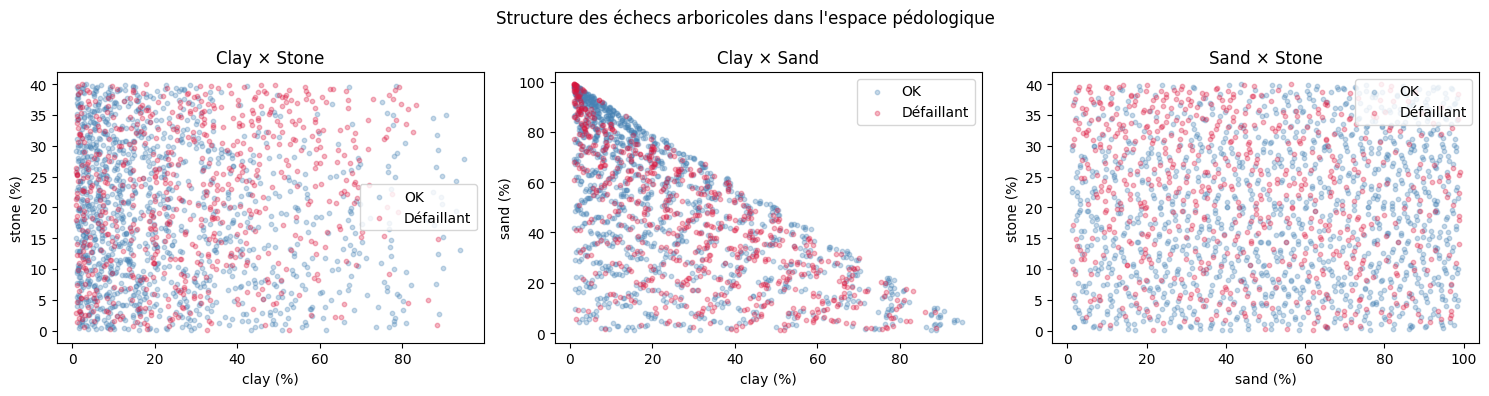

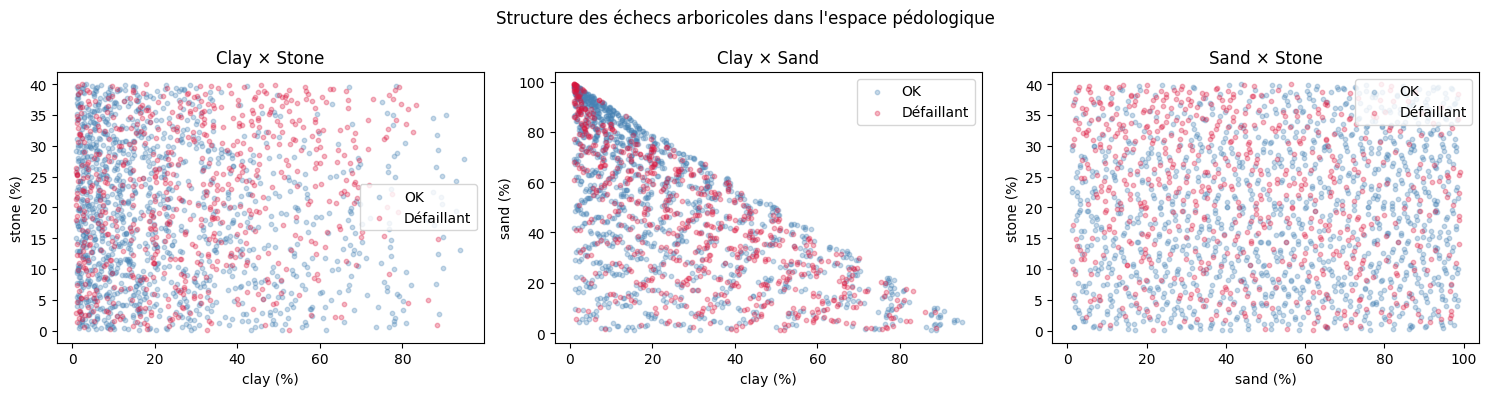

In [ ]:
# --- 2a. Scatter clay × stone coloré par tree_failed ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Clay vs Stone
axes[0].scatter(
    last_cycle.loc[last_cycle['tree_failed']==False, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==False, 'stone'],
    alpha=0.3, s=10, label='OK', color='steelblue'
)
axes[0].scatter(
    last_cycle.loc[last_cycle['tree_failed']==True, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==True, 'stone'],
    alpha=0.3, s=10, label='Défaillant', color='crimson'
)
axes[0].set_xlabel('clay (%)'); axes[0].set_ylabel('stone (%)')
axes[0].set_title('Clay × Stone'); axes[0].legend()

# Clay vs Sand
axes[1].scatter(
    last_cycle.loc[last_cycle['tree_failed']==False, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==False, 'sand'],
    alpha=0.3, s=10, label='OK', color='steelblue'
)
axes[1].scatter(
    last_cycle.loc[last_cycle['tree_failed']==True, 'clay'],
    last_cycle.loc[last_cycle['tree_failed']==True, 'sand'],
    alpha=0.3, s=10, label='Défaillant', color='crimson'
)
axes[1].set_xlabel('clay (%)'); axes[1].set_ylabel('sand (%)')
axes[1].set_title('Clay × Sand'); axes[1].legend()

# Sand vs Stone
axes[2].scatter(
    last_cycle.loc[last_cycle['tree_failed']==False, 'sand'],
    last_cycle.loc[last_cycle['tree_failed']==False, 'stone'],
    alpha=0.3, s=10, label='OK', color='steelblue'
)
axes[2].scatter(
    last_cycle.loc[last_cycle['tree_failed']==True, 'sand'],
    last_cycle.loc[last_cycle['tree_failed']==True, 'stone'],
    alpha=0.3, s=10, label='Défaillant', color='crimson'
)
axes[2].set_xlabel('sand (%)'); axes[2].set_ylabel('stone (%)')
axes[2].set_title('Sand × Stone'); axes[2].legend()

plt.suptitle("Structure des échecs arboricoles dans l'espace pédologique", fontsize=12)
plt.tight_layout()
plt.savefig("tree_fail_soil_space.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
feature_cols = SOBOL_FEATURES

X_tree = last_cycle[feature_cols].copy()
y_tree = last_cycle['tree_failed'].astype(int)

# Masque des lignes complètes
mask = X_tree.notna().all(axis=1)
X_tree, y_tree = X_tree[mask], y_tree[mask]

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
clf.fit(X_tree, y_tree)

print(f"Accuracy : {clf.score(X_tree, y_tree):.3f}")
print(f"\n=== Règles de décision ===")
print(export_text(clf, feature_names=feature_cols))

print("\n=== Importances des features ===")
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.round(4))

Accuracy : 0.720

=== Règles de décision ===
|--- clay <= 18.91
|   |--- longitude <= 1.19
|   |   |--- period <= 0.50
|   |   |   |--- latitude <= 44.34
|   |   |   |   |--- class: 0
|   |   |   |--- latitude >  44.34
|   |   |   |   |--- class: 0
|   |   |--- period >  0.50
|   |   |   |--- sand <= 67.94
|   |   |   |   |--- class: 1
|   |   |   |--- sand >  67.94
|   |   |   |   |--- class: 0
|   |--- longitude >  1.19
|   |   |--- northOrientation <= 169.10
|   |   |   |--- strip_width <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- strip_width >  1.50
|   |   |   |   |--- class: 0
|   |   |--- northOrientation >  169.10
|   |   |   |--- latitude <= 45.57
|   |   |   |   |--- class: 1
|   |   |   |--- latitude >  45.57
|   |   |   |   |--- class: 0
|--- clay >  18.91
|   |--- stone <= 30.44
|   |   |--- longitude <= 1.04
|   |   |   |--- latitude <= 43.07
|   |   |   |   |--- class: 0
|   |   |   |--- latitude >  43.07
|   |   |   |   |--- class: 1
|   |   |--- longitude >  

*Arbre de décision — règles de classification*

L'arbre de décision de profondeur 4 atteint une accuracy de *72%* sur les données d'entraînement, reflétant l'**absence de frontière nette dans l'espace des features** — ce que les scatter plots confirment visuellement par un **fort chevauchement entre les deux populations**.

> La règle principale d'échec identifiée est : *clay > 18.91% AND stone > 30.44% AND clay <= 27.40%*, soit des sols **moyennement argileux et très caillouteux**. 
> 
> La règle secondaire implique une interaction géographique (*longitude <= 1.04 AND latitude > 43.07*), illustrant que **la même texture peut être viable ou non selon le régime climatique local**.
> 
> Les importances des features confirment la hiérarchie : *clay (25.6%) > longitude (18.8%) ≈ sand (18.7%) ≈ stone (16.7%) > latitude (11.1%)*, les *variables de nappe, de profondeur de sol et de géométrie ayant une importance nulle*. 
> 
> Ce résultat est interprétable mécanistiquement : dans Hi-sAFe, la croissance de l'arbre est contrainte par le volume de sol exploitable racinaire, lui-même réduit par les fortes teneurs en argile (compaction, asphyxie) et en cailloux (volume non-exploitable). **La géographie intervient comme modulateur du stress hydrique et thermique qui amplifie ou atténue ces contraintes pédologiques.**

=== Corrélations Spearman (niveau SimID) ===
              mean_yield  final_height  final_carbon
mean_yield         1.000         0.196         0.188
final_height       0.196         1.000         0.990
final_carbon       0.188         0.990         1.000


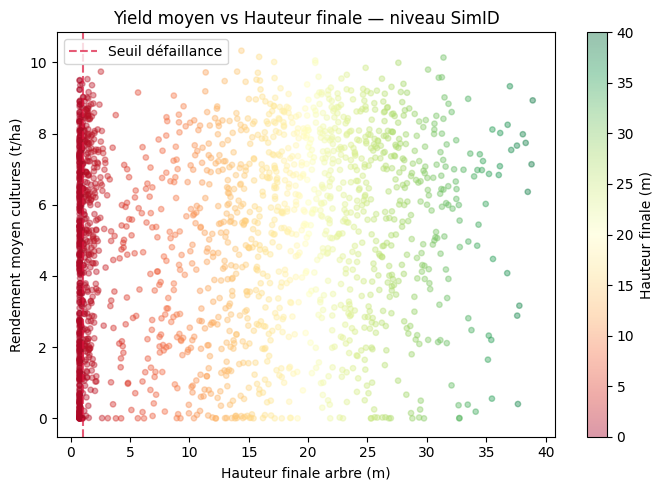

In [18]:
# Au niveau SimID : est-ce que les arbres qui poussent pénalisent la culture ?
sim_summary = df.groupby('SimID').agg(
    mean_yield   = ('yield_AF', 'mean'),
    final_height = ('tree_height_AF', 'last'),
    final_carbon = ('carbonStem_AF', 'last')
).reset_index()

print("=== Corrélations Spearman (niveau SimID) ===")
corr = sim_summary[['mean_yield', 'final_height', 'final_carbon']].corr(method='spearman')
print(corr.round(3))

# Scatter yield moyen vs hauteur finale
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    sim_summary['final_height'],
    sim_summary['mean_yield'],
    alpha=0.4, s=15, c=sim_summary['final_height'],
    cmap='RdYlGn', norm=mcolors.Normalize(vmin=0, vmax=40)
)
plt.colorbar(sc, ax=ax, label='Hauteur finale (m)')
ax.set_xlabel('Hauteur finale arbre (m)')
ax.set_ylabel('Rendement moyen cultures (t/ha)')
ax.set_title('Yield moyen vs Hauteur finale — niveau SimID')
ax.axvline(x=1.0, color='crimson', linestyle='--', alpha=0.7, label='Seuil défaillance')
ax.legend()
plt.tight_layout()
plt.savefig("yield_vs_height_simid.png", dpi=150, bbox_inches='tight')
plt.show()

*Corrélation hauteur × rendement*

La corrélation de Spearman entre la **hauteur finale de l'arbre** et le **rendement moyen de la culture** est **faible et positive** ($ρ = 0.196$), de même que celle entre carbonStem et rendement ($ρ = 0.188$). Cette corrélation positive reflète une cause commune — **un sol et un climat favorables bénéficient simultanément à l'arbre et à la culture** — plutôt qu'un effet direct de compétition arbre→culture, lequel serait attendu négatif. 

Ce résultat important implique que les deux composantes du système agroforestier (arbre et culture) ne peuvent pas être prédites indépendamment par des méta-modèles séparés sans tenir compte de leur déterminisme commun édapho-climatique. Il justifie également l'approche de prédiction des stocks physiques bruts (yield, carbonStem) plutôt que des ratios (RR, LER), ces derniers mélangeant des effets de causes communes et d'interactions directes difficiles à démêler.

# Diagnostic des simulations culturales défaillantes

In [19]:
# --- Paramètres ---
YIELD_FAIL_THRESHOLD = 0.5  # t/ha

plan_snapshot = df[SOBOL_FEATURES + ['SimID']].drop_duplicates('SimID')

sim_yield = df.groupby('SimID').agg(
    n_cycles          = ('yield_AF', 'count'),
    mean_yield_AF     = ('yield_AF', 'mean'),
    zero_rate_AF      = ('yield_AF', lambda x: (x < YIELD_FAIL_THRESHOLD).sum() / len(x)),
    mean_yield_TA     = ('yield_TA', 'mean'),
    zero_rate_TA      = ('yield_TA', lambda x: (x < YIELD_FAIL_THRESHOLD).sum() / len(x)),
).reset_index()

sim_yield = sim_yield.merge(plan_snapshot, on='SimID', how='left')

# --- Flags d'échec ---
FAIL_RATE_THRESHOLD = 0.5  # SimID "défaillant" si >50% de cycles à yield < seuil

sim_yield['yield_AF_failed'] = sim_yield['zero_rate_AF'] > FAIL_RATE_THRESHOLD
sim_yield['yield_TA_failed'] = sim_yield['zero_rate_TA'] > FAIL_RATE_THRESHOLD

print("=" * 55)
print("=== Échecs rendement AF ===")
print(sim_yield['yield_AF_failed'].value_counts())
print(f"Taux d'échec AF : {sim_yield['yield_AF_failed'].mean():.1%}")

print("\n=== Échecs rendement TA ===")
print(sim_yield['yield_TA_failed'].value_counts())
print(f"Taux d'échec TA : {sim_yield['yield_TA_failed'].mean():.1%}")

# --- Matrice de co-occurrence AF × TA ---
print("\n=== Co-occurrence des échecs AF et TA ===")
print(pd.crosstab(
    sim_yield['yield_AF_failed'].map({True: 'AF_failed', False: 'AF_ok'}),
    sim_yield['yield_TA_failed'].map({True: 'TA_failed', False: 'TA_ok'}),
    margins=True
))

# --- Comparaison features numériques : OK vs défaillants ---
def compare_features(df_sim, fail_col, num_cols):
    comp = df_sim.groupby(fail_col)[num_cols].mean().T.round(3)
    comp.columns = ['OK (False)', 'Défaillant (True)']
    comp['delta'] = comp['Défaillant (True)'] - comp['OK (False)']
    comp['delta_%'] = (comp['delta'] / comp['OK (False)'].abs() * 100).round(1)
    return comp.sort_values('delta', key=abs, ascending=False)

print("\n=== Features numériques — Échec yield_AF ===")
print(compare_features(sim_yield, 'yield_AF_failed', num_features))

print("\n=== Features numériques — Échec yield_TA ===")
print(compare_features(sim_yield, 'yield_TA_failed', num_features))

# --- Distribution par main_crop ---
print("\n=== main_crop — Échec yield_AF ===")
print(pd.crosstab(sim_yield['yield_AF_failed'], sim_yield['main_crop'], normalize='index').round(3))

print("\n=== main_crop — Échec yield_TA ===")
print(pd.crosstab(sim_yield['yield_TA_failed'], sim_yield['main_crop'], normalize='index').round(3))

# --- Arbres de décision AF et TA ---
def fit_decision_tree(df_sim, fail_col, feature_cols, depth=4):
    X = df_sim[feature_cols].copy()
    y = df_sim[fail_col].astype(int)
    mask = X.notna().all(axis=1)
    X, y = X[mask], y[mask]
    clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=42)
    clf.fit(X, y)
    print(f"  Accuracy : {clf.score(X, y):.3f}")
    print(export_text(clf, feature_names=feature_cols))
    imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print("  Importances :")
    print(imp[imp > 0].round(4))
    return clf

print("\n" + "=" * 55)
print("=== Arbre de décision — Échec yield_AF ===")
clf_AF = fit_decision_tree(sim_yield, 'yield_AF_failed', num_features)

print("\n=== Arbre de décision — Échec yield_TA ===")
clf_TA = fit_decision_tree(sim_yield, 'yield_TA_failed', num_features)

# --- Quadrant : 4 cas possibles AF × TA ---
print("\n=== Analyse par quadrant AF × TA ===")
sim_yield['quadrant'] = 'unknown'
sim_yield.loc[~sim_yield['yield_AF_failed'] & ~sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_ok × TA_ok'
sim_yield.loc[ sim_yield['yield_AF_failed'] & ~sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_fail × TA_ok'
sim_yield.loc[~sim_yield['yield_AF_failed'] &  sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_ok × TA_fail'
sim_yield.loc[ sim_yield['yield_AF_failed'] &  sim_yield['yield_TA_failed'], 'quadrant'] = 'AF_fail × TA_fail'

print(sim_yield['quadrant'].value_counts())
print("\nFeatures moyennes par quadrant :")
print(sim_yield.groupby('quadrant')[num_features].mean().T.round(3))

=== Échecs rendement AF ===
yield_AF_failed
False    1671
True      266
Name: count, dtype: int64
Taux d'échec AF : 13.7%

=== Échecs rendement TA ===
yield_TA_failed
False    1648
True      289
Name: count, dtype: int64
Taux d'échec TA : 14.9%

=== Co-occurrence des échecs AF et TA ===
yield_TA_failed  TA_failed  TA_ok   All
yield_AF_failed                        
AF_failed              236     30   266
AF_ok                   53   1618  1671
All                    289   1648  1937

=== Features numériques — Échec yield_AF ===
                  OK (False)  Défaillant (True)  delta  delta_%
stone                 19.131             25.253  6.122     32.0
longitude              1.860              4.778  2.918    156.9
latitude              46.322             43.968 -2.354     -5.1
sand                  50.206             48.400 -1.806     -3.6
clay                  25.324             26.952  1.628      6.4
w_peak_doy            60.281             61.387  1.106      1.8
northOrientation  

*Taux d'échec et co-occurrence*

Le taux d'échec du rendement est de $13.7\%$ pour le système *AF* et de $14.9\%$ pour le témoin *TA*, des valeurs remarquablement proches. La matrice de co-occurrence révèle que $88.7\%$ des échecs *AF* sont aussi des échecs *TA* ($236$ sur $266$ *SimIDs* défaillants en *AF*), confirmant que **la défaillance culturale est quasi-exclusivement d'origine édapho-climatique et non liée à la compétition arbre-culture**. Les quadrants marginaux — *AF_fail × TA_ok* ($30$ *SimIDs*, $1.5\%$) et *AF_ok × TA_fail* ($53$ *SimIDs*, $2.7\%$) — représentent respectivement le signal de **compétition pure de l'arbre sur la culture et un possible effet de facilitation ou de protection**, mais leur faible effectif rend toute conclusion fragile à ce stade.

*Structure des échecs — rôle dominant de la géographie*

Contrairement aux échecs arboricoles dominés par la pédologie, **les échecs de rendement sont gouvernés par la géographie** : la ***longitude* est la feature la plus discriminante pour *yield_AF*** (importance $41.2\%$) et la ***latitude* pour *yield_TA*** ($42.7\%$). 

La latitude basse ($<44°N$) combinée à une longitude élevée ($>4-5°E$) définit une zone géographique caractérisée par un régime climatique méditerranéen à continental sec, défavorable aux cultures tempérées modélisées. *soilDepth* et *waterTable* ont une **importance nulle dans tous les arbres de décision, suggérant que leur effet sur les rendements est masqué ou non-discriminant à l'échelle des défaillances binaires.**


*Dissociation AF vs TA — rôle amplifié de la longitude en AF*

Un résultat subtil mais important émerge de la comparaison des importances entre les deux arbres de décision : **la longitude est proportionnellement plus importante pour *yield_AF* ($41\%$) que pour *yield_TA* ($34\%$)**, la latitude jouant le rôle inverse. 

--> **Cela suggère que dans les zones à régime continental (longitude élevée), la présence de l'arbre amplifie le stress hydrique ou thermique subi par la culture, au-delà de ce que subit la monoculture dans les mêmes conditions.** Il se pourrait que dans ces contextes, l'arbre capte une fraction plus importante des ressources limitantes (eau, rayonnement) au détriment de la culture, transformant un stress modéré en monoculture en un échec complet en système AF.

*Analyse par quadrant*

L'analyse des features moyennes par quadrant enrichit cette lecture. 

Le quadrant *AF_fail × TA_ok* (**compétition pure, 30 *SimIDs***) se distingue par une **longitude modérée** (2.34°E, proche de la zone nominale) mais une *northOrientation* **notablement élevée** (**106.7° vs 90° en nominal**) et une **proportion de *waterTable*=1 plus forte (0.60)**. 

--> **Cela suggère que dans ce sous-groupe, l'orientation de la parcelle (ombrage plus marqué selon l'orientation) et la présence d'une nappe (potentiellement captée préférentiellement par les racines profondes de l'arbre) seraient des facteurs de compétition spécifiques.** 

Le quadrant *AF_ok × TA_fail* (*53 SimIDs*) présente la **latitude la plus basse (43.1°E) mais une teneur en sable plus élevée (56.2%)** — un sol sableux en zone méditerranéenne offre une **meilleure disponibilité hydrique ponctuellement** (drainage rapide mais réserve capillaire), ce qui pourrait expliquer pourquoi le système AF s'en sort mieux que la monoculture grâce à l'accès racinaire profond de l'arbre.


In [28]:
# Merge des deux critères sur SimID
check = sim_yield[['SimID', 'yield_AF_failed', 'yield_TA_failed']].merge(
    last_cycle[['SimID', 'tree_failed']],
    on='SimID', how='inner'
)

# Population nominale rendement seul (critère actuel)
mask_yield_ok = ~check['yield_AF_failed'] & ~check['yield_TA_failed']

# Sous-ensemble : nominaux rendement MAIS tree_failed
mask_problematic = mask_yield_ok & check['tree_failed']

print(f"Nominaux (yield seul)            : {mask_yield_ok.sum()}")
print(f"Dont tree_failed                 : {mask_problematic.sum()}")
print(f"Part sur nominaux yield          : {mask_problematic.sum() / mask_yield_ok.sum():.1%}")
print(f"Part sur total SimIDs            : {mask_problematic.sum() / len(check):.1%}")

Nominaux (yield seul)            : 1618
Dont tree_failed                 : 527
Part sur nominaux yield          : 32.6%
Part sur total SimIDs            : 27.2%


In [29]:
check['population'] = 'unknown'

check.loc[
     mask_yield_ok & ~check['tree_failed'], 'population'
] = 'yield_ok × tree_ok'

check.loc[
     mask_yield_ok & check['tree_failed'], 'population'
] = 'yield_ok × tree_failed'

check.loc[
    ~mask_yield_ok & ~check['tree_failed'], 'population'
] = 'yield_fail × tree_ok'

check.loc[
    ~mask_yield_ok & check['tree_failed'], 'population'
] = 'yield_fail × tree_failed'

print(check['population'].value_counts())
print((check['population'].value_counts() / len(check) * 100).round(1))

population
yield_ok × tree_ok          1091
yield_ok × tree_failed       527
yield_fail × tree_ok         186
yield_fail × tree_failed     133
Name: count, dtype: int64
population
yield_ok × tree_ok          56.3
yield_ok × tree_failed      27.2
yield_fail × tree_ok         9.6
yield_fail × tree_failed     6.9
Name: count, dtype: float64


Synthèse et implications pour la modélisation

Deux types d'échec, deux mécanismes distincts

    L'ensemble de ces analyses met en évidence deux types d'échec structurellement distincts dans les données de simulation Hi-sAFe.

    Les échecs arboricoles affectent 36.8% des SimIDs (yield_ok × tree_failed : 27.2% + yield_fail × tree_failed : 6.9% + yield_fail × tree_ok partiel) et sont déterminés par des conditions pédologiques extrêmes — principalement la combinaison argile élevée et forte teneur en cailloux — indépendamment des conditions culturales.

    Les échecs culturaux affectent 16.5% des SimIDs (yield_fail × tree_ok : 9.6% + yield_fail × tree_failed : 6.9%) et sont au contraire dominés par la géographie et le régime climatique — principalement les zones Sud-Est à caractère continental ou méditerranéen sec — quasi-identiques entre système AF et témoin TA.

    Ces deux types d'échec se recoupent partiellement : seulement 6.9% des SimIDs échouent sur les deux critères simultanément (yield_fail × tree_failed), confirmant que les mécanismes pédologique et climatique opèrent largement de manière indépendante.

Une structure en quatre populations, pas trois

    Un résultat inattendu et structurellement important émerge de la combinaison des deux critères : la population initialement qualifiée de "nominale" sur le seul critère de rendement (AF_ok × TA_ok, 83% des SimIDs) se révèle hétérogène à hauteur de 32.6%, soit 527 SimIDs présentant des rendements corrects mais un arbre non fonctionnel (carbonStem_AF < 1 kgC à l'année 40).

    Cette population yield_ok × tree_failed (27.2% du total) correspond mécanistiquement à des conditions pédologiques suffisamment tolérées par la culture mais létales pour l'arbre — sol argileux-caillouteux limitant le volume racinaire exploitable de l'arbre sans affecter significativement une culture annuelle à système racinaire superficiel.

    Le plan d'expérience Sobol révèle ainsi quatre populations fonctionnellement distinctes :
    Population	N	%	Caractérisation
    yield_ok × tree_ok	1091	56.3%	Système AF pleinement fonctionnel
    yield_ok × tree_failed	527	27.2%	Système cultural viable, composante arboricole absente
    yield_fail × tree_ok	186	9.6%	Arbre viable, culture en échec climatique
    yield_fail × tree_failed	133	6.9%	Échec total édapho-climatique

Implications pour le méta-modèle

    Cette structure en quatre populations a des conséquences directes et plus contraignantes qu'anticipé sur l'architecture du méta-modèle.

    La population nominale est redéfinie strictement comme yield_ok × tree_ok (1091 SimIDs, 56.3%), seule configuration où l'ensemble des targets — yield_AF, yield_TA, carbonStem_AF, carbonStem_TF — suit une distribution unimodale et physiquement cohérente. C'est sur cette population que le méta-modèle principal sera entraîné.

    La population yield_ok × tree_failed (527 SimIDs, 27.2%) constitue un cas d'usage distinct : yield_AF et yield_TA y sont modélisables normalement, mais carbonStem_AF est structurellement nul. Un méta-modèle cultural dédié (yield uniquement, sans composante carbone) pourrait y être entraîné, ou ces SimIDs peuvent être traités par une règle analytique simple (carbonStem_AF ≈ 0 si conditions pédologiques létales pour l'arbre, identifiées par les règles de l'arbre de décision clay > 18.9% AND stone > 30.4%).

    Les populations yield_fail × tree_ok (9.6%) et yield_fail × tree_failed (6.9%) représentent des régimes climatiques extrêmes (zones méditerranéennes et continentales sèches) pour lesquels aucun méta-modèle n'est envisagé en première intention — une règle de rejet géographique (latitude, longitude) suffit à les identifier avec une accuracy > 70% comme montré par les arbres de décision.

    Avant l'entraînement du méta-modèle principal, une analyse de sensibilité HSIC sera conduite sur la population yield_ok × tree_ok afin d'identifier les features réellement influentes pour chaque target, d'orienter la sélection de variables et de valider la cohérence physique du méta-modèle sur une population homogène et pleinement fonctionnelle.
